In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

In [2]:
#%matplotlib inline
auto_plot_style()

In [3]:
def sipm_positions(conf):
    conf   = conf["geometry"]["sipm_plane"]
    size   = conf["sipm_size"]
    gap    = conf["sipm_gap"]
    n      = conf["n_sipms_side"]
    offset = n * (size + gap) / 2.
    xy     = (np.arange(n) + 0.5) * (size + gap) - offset
    return (xy, *np.meshgrid(xy, xy, indexing="ij"))

def extent(conf):
    conf   = conf["geometry"]["sipm_plane"]
    size   = conf["sipm_size"]
    gap    = conf["sipm_gap"]
    n      = conf["n_sipms_side"]
    offset = n * (size + gap) / 2.
    return (-offset, offset) * 2

def npmap(f, it):
    return np.array(list(map(f, it)))

def read_csv(filename):
    df = pd.read_csv(filetest , sep=" ", header=0)
    df.insert(3, "r0", (df.x0**2 + df.y0**2)**0.5)
    return df

def barycenter(df, sipm_x, sipm_y, nsipms):
    img = df.iloc[0, -nsipms**2:].values.reshape(nsipms, nsipms).T
    tot = img.sum()
    xb  = (sipm_x * img).sum() / tot
    yb  = (sipm_y * img).sum() / tot
    return pd.Series(dict(x=xb, y=yb))

In [4]:
rbins  = np.linspace(  0, 16, 81)
xybins = np.linspace(-16, 16, 81)
drbins = np.linspace(  0, 16, 81)

In [5]:
folder    = Path("../data/pcolina/6x6/0.50/25um/")
filetrain = folder / "images_train.csv"
filetest  = folder / "images_test.csv"
train     = read_csv(filetrain)
test      = read_csv(filetest )
output    = folder / "reco.h5"
conf      = tomllib.loads(open(folder / "run.conf").read())
nsipms    = conf["geometry"]["sipm_plane"]["n_sipms_side"]
nwires    = conf["geometry"]["wire_plane"]["n_wires"]
pwires    = conf["geometry"]["wire_plane"]["wire_pitch"]
wire_pos  = np.arange(nwires) * pwires - (nwires-1)*pwires/2
sipm_pos  = sipm_positions(conf)[0]
sipm_x    = sipm_positions(conf)[1]
sipm_y    = sipm_positions(conf)[2]
extents   = extent(conf)
ticks     = np.arange(-30, 31, 10)
print(conf)

{'n_events': 1000000, 'output': '../data/pcolina/6x6/0.50/25um/', 'geometry': {'buffer': 3.0, 'wire_plane': {'wire_pitch': 5.0, 'wire_r': 0.0125, 'wire_rotation': 45.0, 'n_wires': 14}, 'sipm_plane': {'sipm_size': 6.0, 'sipm_area': 34.8075, 'sipm_gap': 0.5, 'n_sipms_side': 5}, 'el_gap': {'el_r': 16.0, 'el_gap_front': 5.0, 'el_gap_back': 5.0}}, 'sim_params': {'dep_energy': 5898.75, 'w_i': 15.6, 'light_yield': 30.0, 'el_range': 0.04, 'cloud_r': 0.02, 'fano_factor': 0.05}}


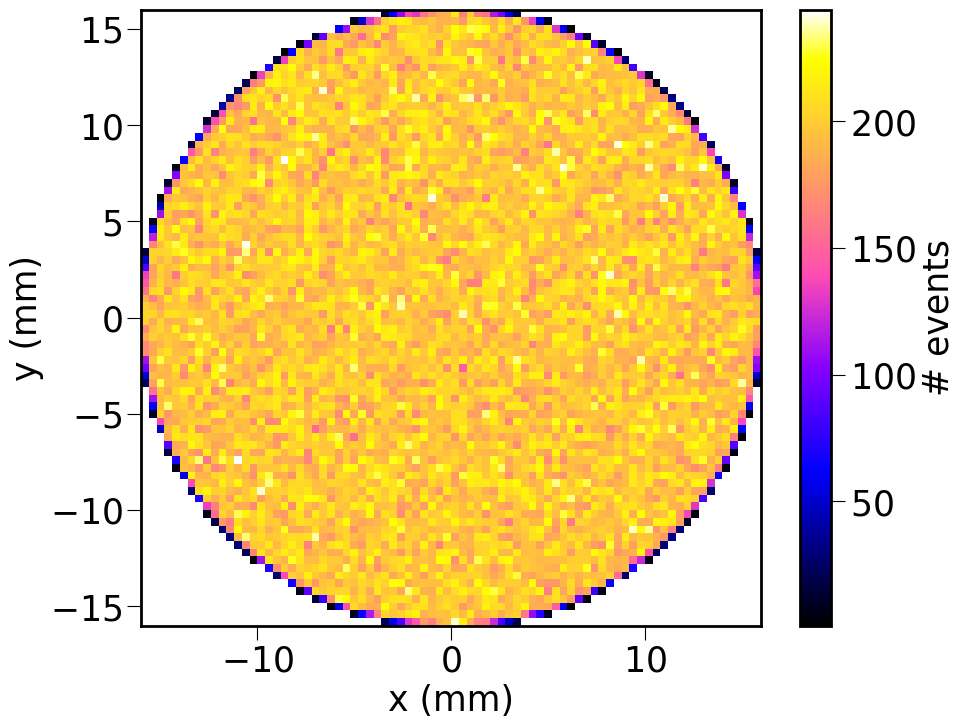

In [6]:
y = plt.hist2d(test.x0, test.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

Text(0, 0.5, 'wire charge (e-)')

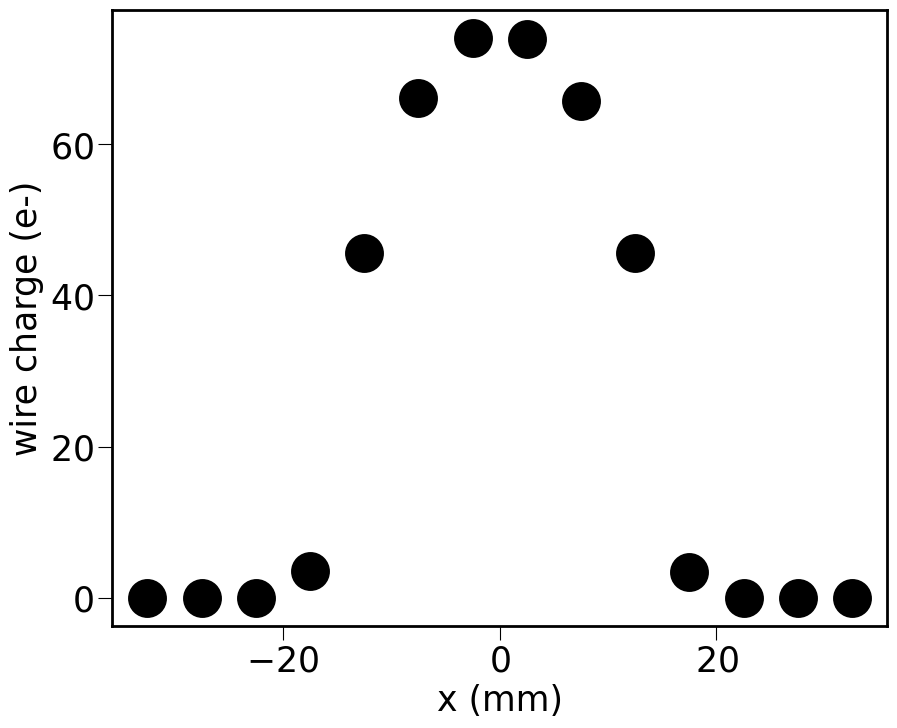

In [7]:
q = test.filter(regex="w_*").values.mean(axis=0)
plt.scatter(wire_pos, q)
plt.xlabel("x (mm)")
plt.ylabel("wire charge (e-)")

# Barycenter

In [8]:
df = test.groupby(level=0).apply(barycenter, sipm_x, sipm_y, nsipms)
df = test.filter("x0 y0 r0".split()).join(df)
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [9]:
reco_bb

,x0,y0,r0,x,y,dx,dy,dr
0,-1.767633,-14.932930,15.037184,-2.315265,-7.372419,-0.547633,7.560511,7.580318
1,-8.556936,-4.352665,9.600357,-5.372259,-3.826263,3.184677,0.526402,3.227889
2,-13.062822,4.363532,13.772353,-8.043192,3.919336,5.019629,-0.444195,5.039245
3,-4.928335,9.280847,10.508217,-4.067968,7.115298,0.860368,-2.165549,2.330201
4,-10.989004,-7.359574,13.225790,-7.081354,-5.764275,3.907649,1.595299,4.220747
...,...,...,...,...,...,...,...,...
999995,-15.349733,3.599069,15.766027,-7.897409,2.121148,7.452324,-1.477921,7.597459
999996,6.447406,-2.305508,6.847219,5.227853,-2.951380,-1.219553,-0.645873,1.380022
999997,3.198898,-0.875269,3.316481,1.552987,0.254656,-1.645911,1.129925,1.996436
999998,-11.244277,4.309097,12.041681,-7.633721,3.905039,3.610556,-0.404058,3.633094


In [10]:
imgs =  test.filter(regex="img_*").values.reshape(10**6, nsipms, nsipms)
xx = np.sum(imgs.sum(axis=2) * (np.arange(nsipms) + 0.5) * 3, axis=1) / imgs.sum(axis=2).sum(axis=1) + extents[0]
yy = np.sum(imgs.sum(axis=1) * (np.arange(nsipms) + 0.5) * 3, axis=1) / imgs.sum(axis=2).sum(axis=1) + extents[0]

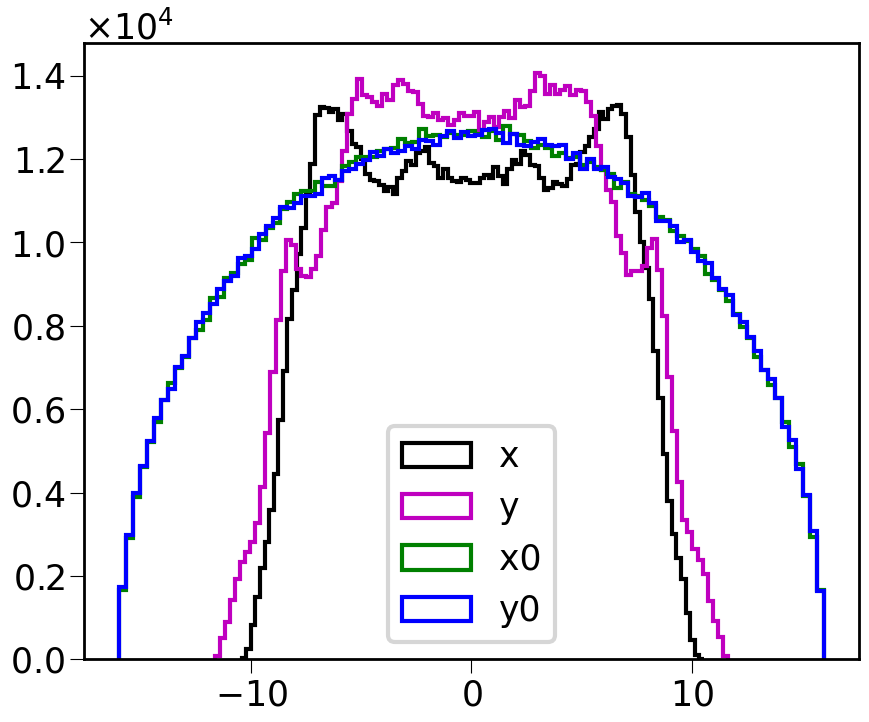

In [11]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

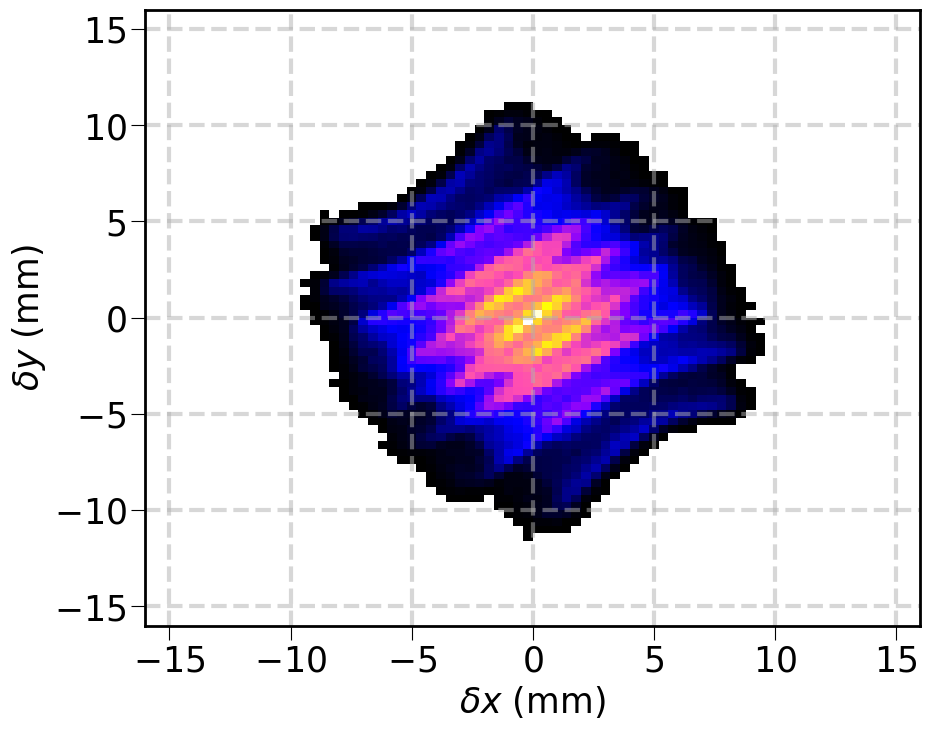

In [12]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

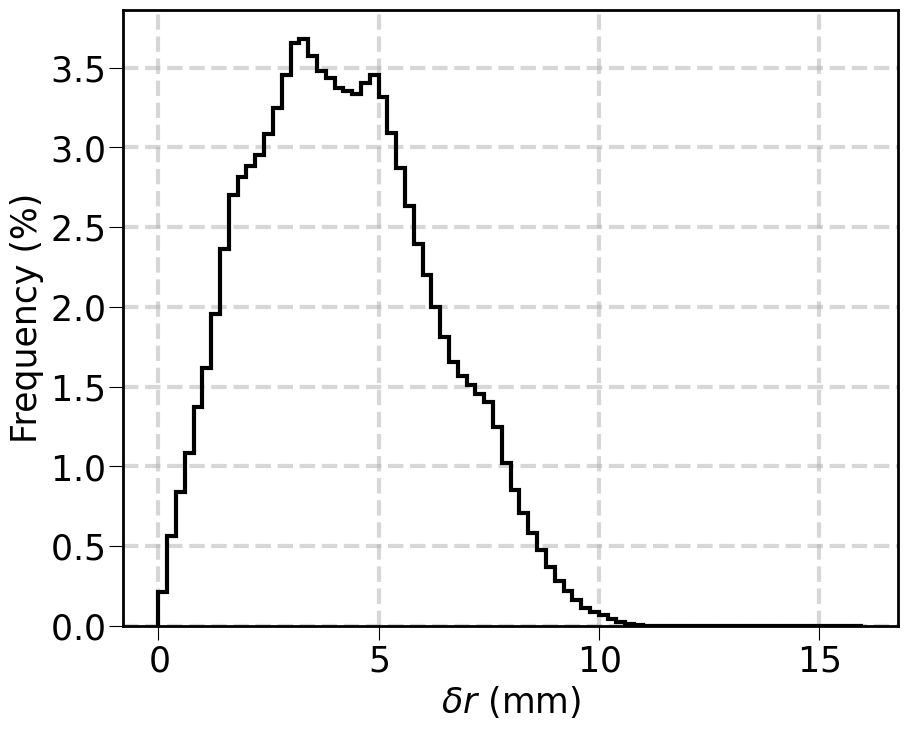

In [13]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

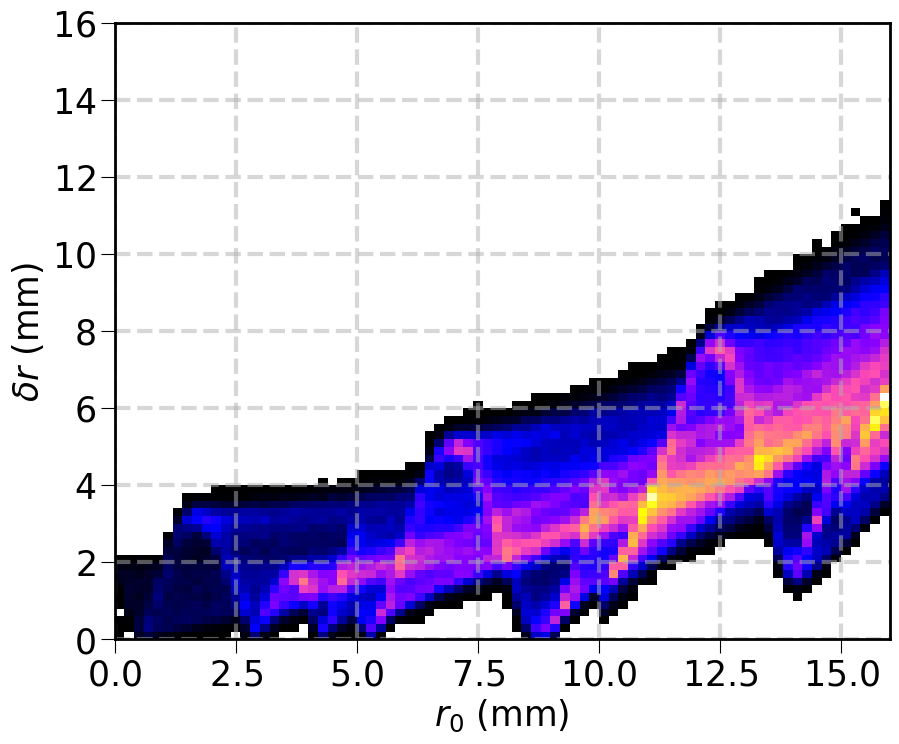

In [14]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

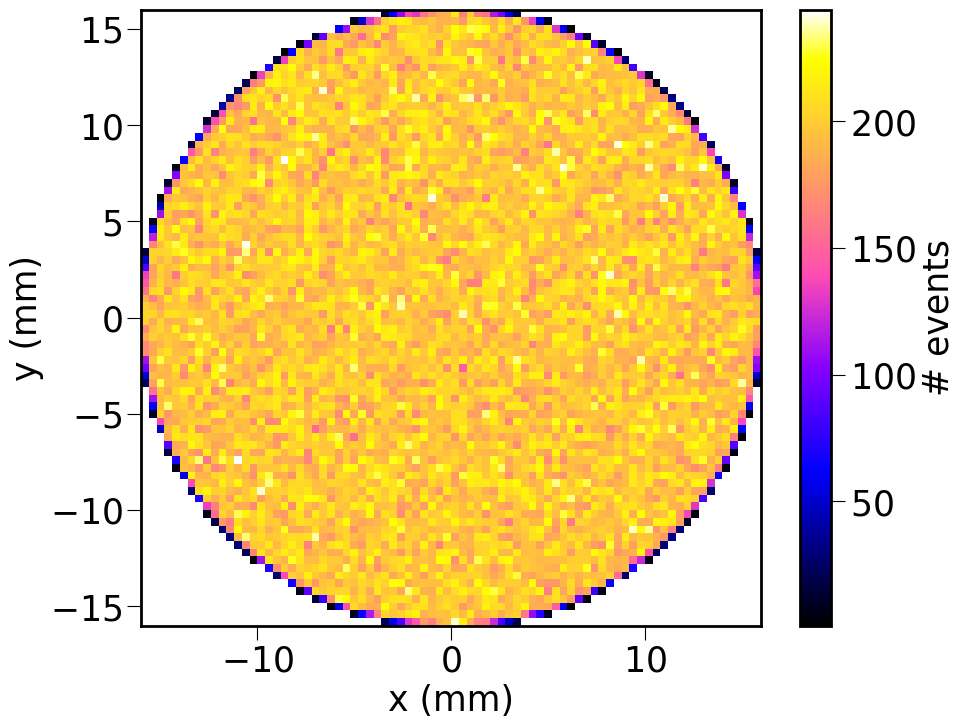

In [15]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

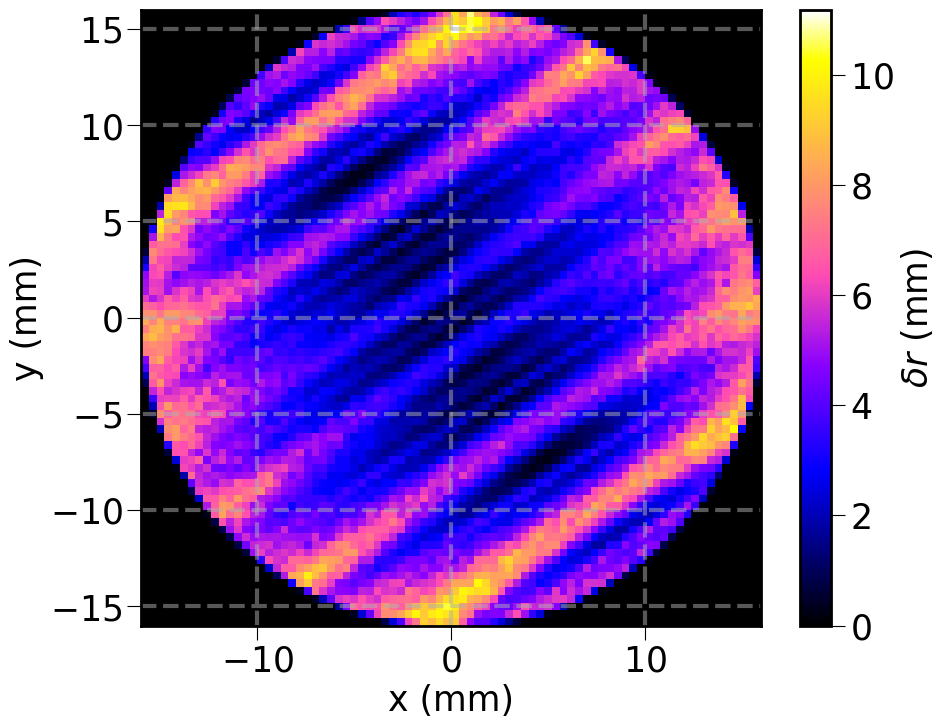

In [16]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

# NN

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

In [18]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [19]:
n_train   = len(train)
n_test    = len(test)
img_train = train.filter(regex="img*").values.reshape(n_train, nsipms, nsipms).astype(float)
img_test  = test .filter(regex="img*").values.reshape(n_test , nsipms, nsipms).astype(float)
img_train = img_train.swapaxes(1, 2)
img_test  = img_test .swapaxes(1, 2)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [20]:
model     = Linear(nsipms, nsipms)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
epochs = 50
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 50 of 50 | 1.49 s/item | ETA 0.0 min | Ellapsed 1.2 min


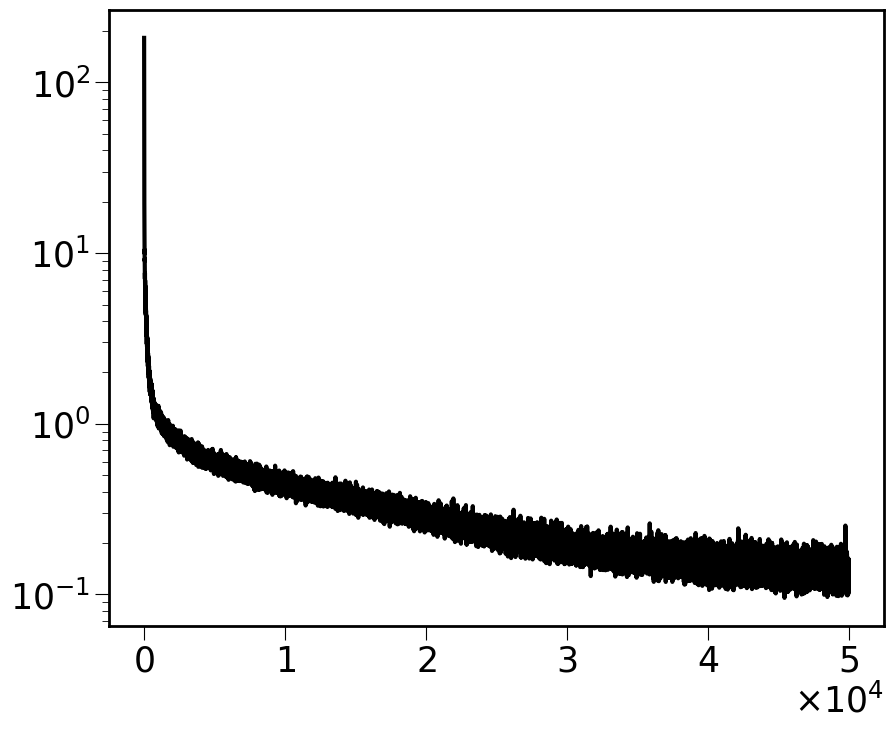

In [22]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [23]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

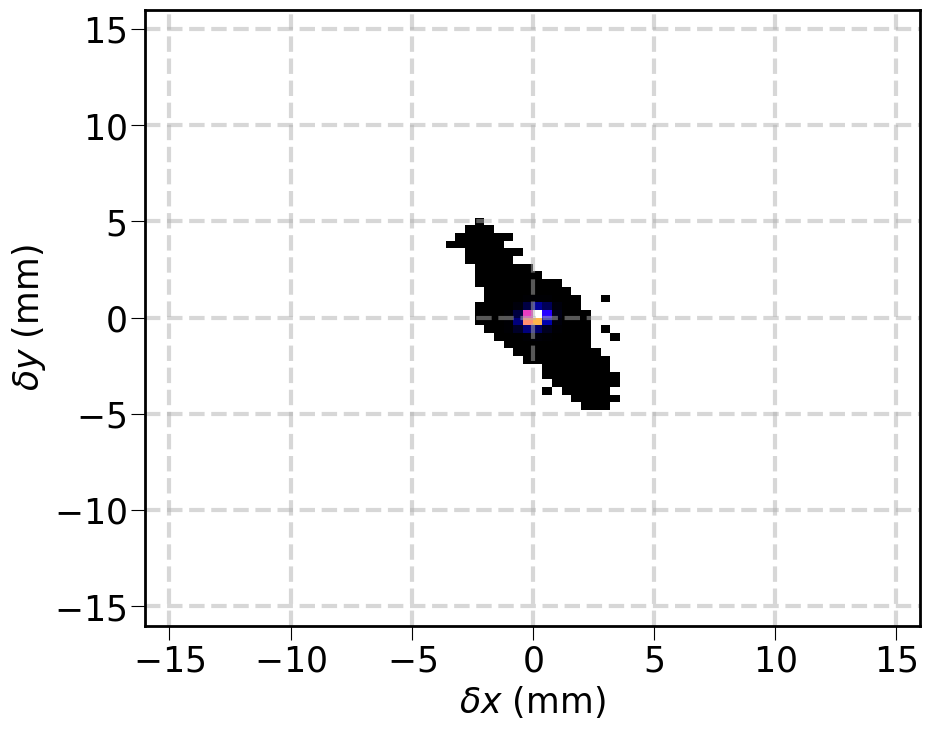

In [24]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

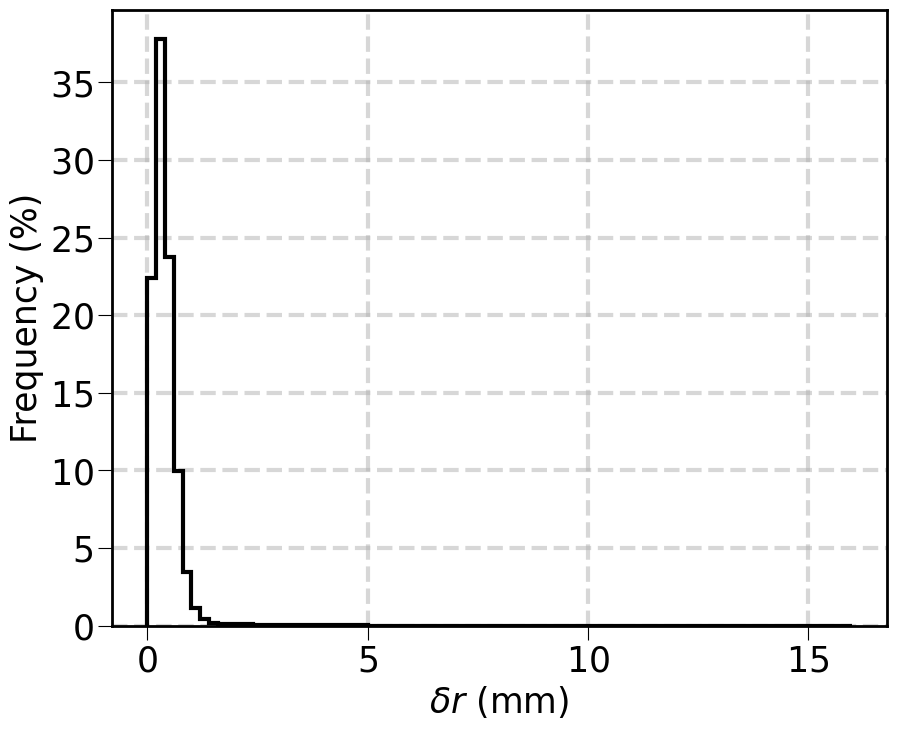

In [25]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

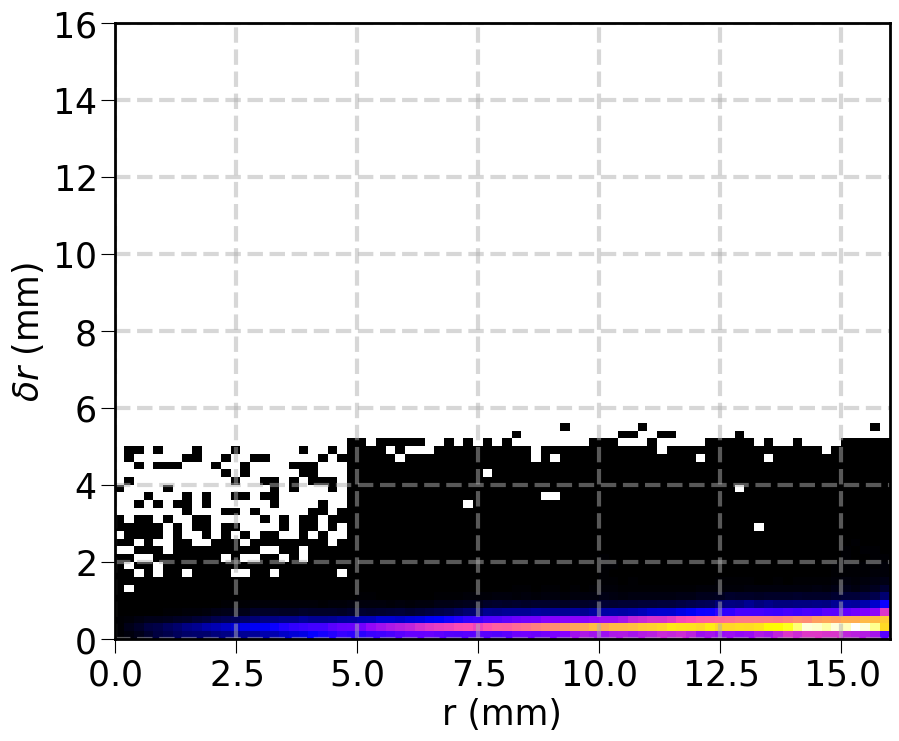

In [26]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

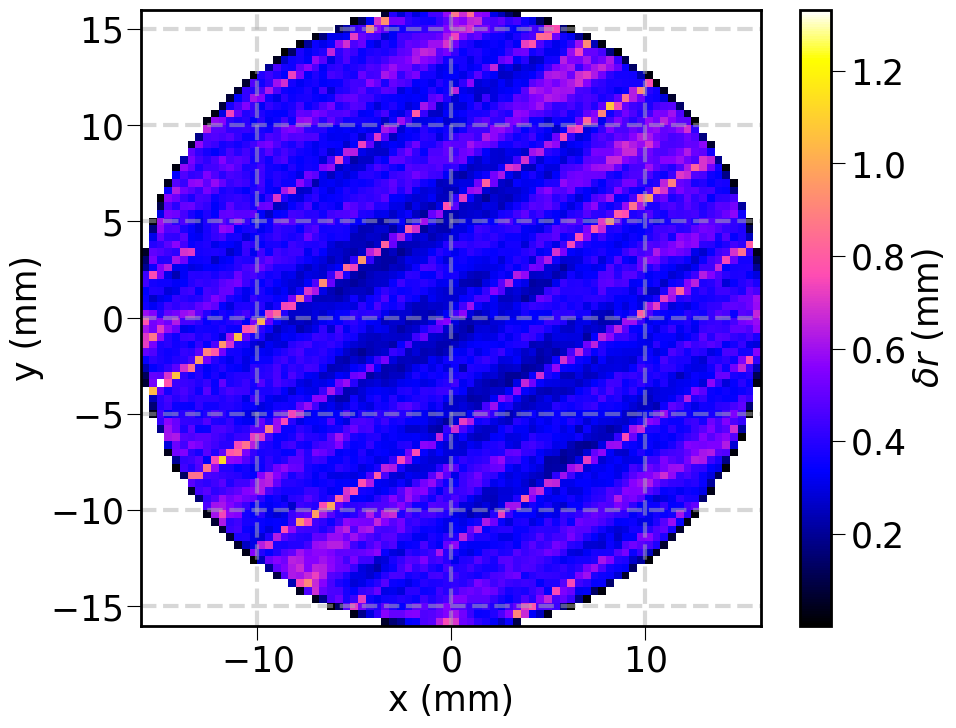

In [27]:
plt.hist2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr/evt_per_bin, cmin=1e-3)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

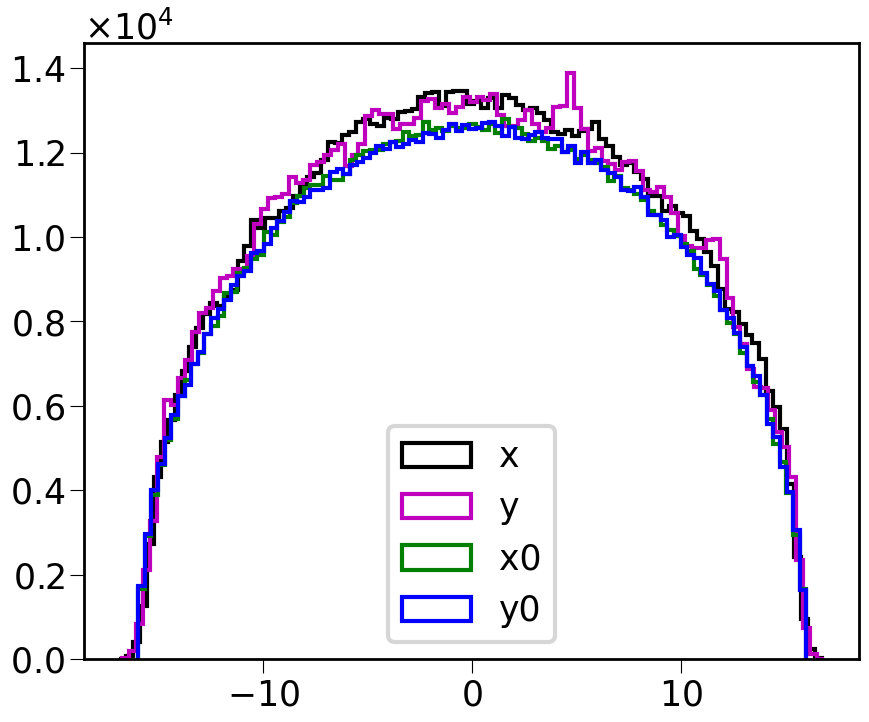

In [28]:
plt.hist(reco_nn.x , 101, histtype="step", label="x");
plt.hist(reco_nn.y , 101, histtype="step", label="y");
plt.hist(reco_nn.x0, 101, histtype="step", label="x0");
plt.hist(reco_nn.y0, 101, histtype="step", label="y0");
plt.legend()

In [29]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
0,-1.767633,-14.932930,15.037184,-1.669243,-15.023207,0.098390,-0.090277,0.133531
1,-8.556936,-4.352665,9.600357,-7.980200,-4.031803,0.576736,0.320862,0.659983
2,-13.062822,4.363532,13.772353,-12.714380,4.200193,0.348442,-0.163339,0.384827
3,-4.928335,9.280847,10.508217,-4.637556,9.363155,0.290780,0.082307,0.302204
4,-10.989004,-7.359574,13.225790,-10.721936,-7.674867,0.267068,-0.315293,0.413201
...,...,...,...,...,...,...,...,...
999995,-15.349733,3.599069,15.766027,-14.753126,3.747703,0.596608,0.148634,0.614844
999996,6.447406,-2.305508,6.847219,6.441365,-2.082120,-0.006041,0.223388,0.223470
999997,3.198898,-0.875269,3.316481,3.067275,-1.073316,-0.131623,-0.198047,0.237797
999998,-11.244277,4.309097,12.041681,-10.677136,4.387750,0.567140,0.078654,0.572568


In [30]:
reco = pd.DataFrame.join( reco_bb
                        , reco_nn.drop(columns="x0 y0 r0".split())
                        , lsuffix="_bb"
                        , rsuffix="_nn")

In [31]:
reco

,x0,y0,r0,x_bb,y_bb,dx_bb,dy_bb,dr_bb,x_nn,y_nn,dx_nn,dy_nn,dr_nn
0,-1.767633,-14.932930,15.037184,-2.315265,-7.372419,-0.547633,7.560511,7.580318,-1.669243,-15.023207,0.098390,-0.090277,0.133531
1,-8.556936,-4.352665,9.600357,-5.372259,-3.826263,3.184677,0.526402,3.227889,-7.980200,-4.031803,0.576736,0.320862,0.659983
2,-13.062822,4.363532,13.772353,-8.043192,3.919336,5.019629,-0.444195,5.039245,-12.714380,4.200193,0.348442,-0.163339,0.384827
3,-4.928335,9.280847,10.508217,-4.067968,7.115298,0.860368,-2.165549,2.330201,-4.637556,9.363155,0.290780,0.082307,0.302204
4,-10.989004,-7.359574,13.225790,-7.081354,-5.764275,3.907649,1.595299,4.220747,-10.721936,-7.674867,0.267068,-0.315293,0.413201
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-15.349733,3.599069,15.766027,-7.897409,2.121148,7.452324,-1.477921,7.597459,-14.753126,3.747703,0.596608,0.148634,0.614844
999996,6.447406,-2.305508,6.847219,5.227853,-2.951380,-1.219553,-0.645873,1.380022,6.441365,-2.082120,-0.006041,0.223388,0.223470
999997,3.198898,-0.875269,3.316481,1.552987,0.254656,-1.645911,1.129925,1.996436,3.067275,-1.073316,-0.131623,-0.198047,0.237797
999998,-11.244277,4.309097,12.041681,-7.633721,3.905039,3.610556,-0.404058,3.633094,-10.677136,4.387750,0.567140,0.078654,0.572568


In [32]:
reco.to_hdf(output, key="/data", complib="zlib", complevel=4)

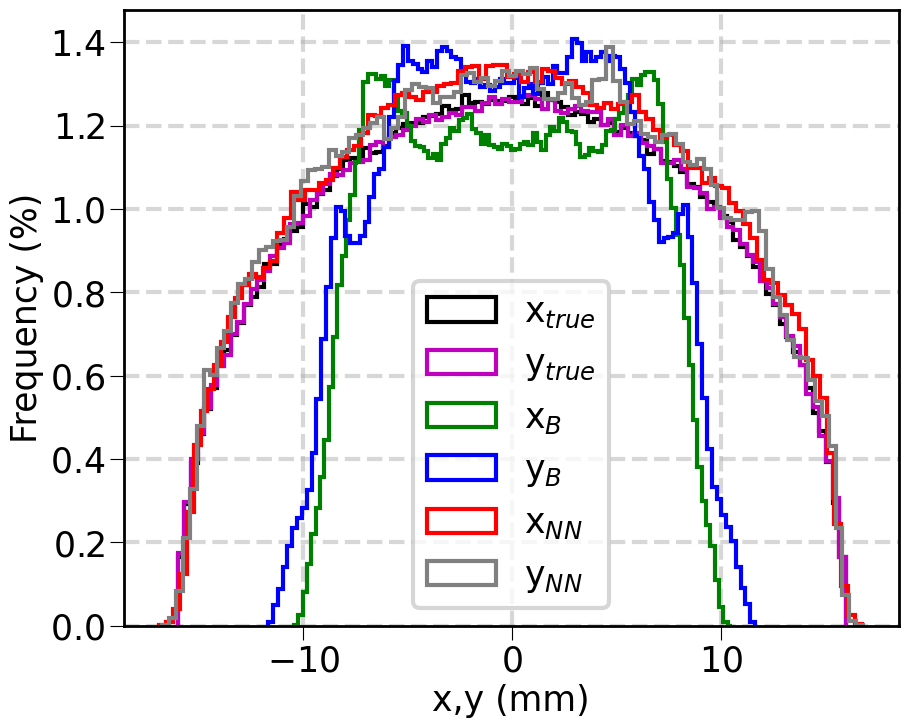

In [33]:
normhist(reco.x0  , 101, histtype="step", label="x$_{true}$");
normhist(reco.y0  , 101, histtype="step", label="y$_{true}$");
normhist(reco.x_bb, 101, histtype="step", label="x$_{B}$");
normhist(reco.y_bb, 101, histtype="step", label="y$_{B}$");
normhist(reco.x_nn, 101, histtype="step", label="x$_{NN}$");
normhist(reco.y_nn, 101, histtype="step", label="y$_{NN}$");
plt.legend()
plt.xlabel("x,y (mm)")
plt.ylabel("Frequency (%)")
plt.grid()